# System Call Intrusion Detection Using TF-IDF and kNN

## Objective

The objective of this project is to detect intrusive processes using system-call sequences.

The approach uses:

1. System-call sequence preprocessing
2. TF-IDF-inspired feature weighting
3. Cosine similarity
4. k-Nearest Neighbors (kNN) anomaly scoring
5. Threshold-based intrusion detection
6. ROC-AUC, TPR, FPR, Precision, Recall, and F1 evaluation

The model is trained using normal processes only and evaluated on a test set containing both normal and intrusive processes.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

%matplotlib inline

In [2]:
# Load process-level syscall dataset

df = pd.read_csv("process_syscalls_final_k_separated.csv")

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (880, 4)


,process_id,label,split,syscalls
0,1,normal,train,sigreturn prlimit64 getpid shmat bind readv re...
1,2,normal,train,readv fcntl truncate getppid read mkdir fork g...
2,3,normal,train,fsync gettimeofday getppid uname readv pwrite6...
3,4,normal,train,readv dup2 setsid prlimit64 getuid nanosleep r...
4,5,normal,train,rename uname fcntl mmap clock_gettime write du...


In [3]:
# Required columns
required_cols = {
    "process_id",
    "label",
    "split",
    "syscalls"
}

missing = required_cols - set(df.columns)

if missing:
    raise ValueError(f"Missing columns in CSV: {missing}")

# Standardize text columns
df["label"] = df["label"].astype(str).str.lower().str.strip()
df["split"] = df["split"].astype(str).str.lower().str.strip()

print("Required columns found.")
print("\nColumns:")
print(df.columns.tolist())

Required columns found.

Columns:
['process_id', 'label', 'split', 'syscalls']


In [4]:
print("Missing values:")
display(df[["process_id", "label", "split", "syscalls"]].isnull().sum())

print("\nDuplicate process IDs:")
print(df["process_id"].duplicated().sum())

print("\nEmpty syscall sequences:")
empty_syscalls = (
    df["syscalls"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print(empty_syscalls)

Missing values:


,0
process_id,0
label,0
split,0
syscalls,0



Duplicate process IDs:
0

Empty syscall sequences:
0


In [5]:
print("Total processes:", len(df))

print("\nLabel distribution:")
display(df["label"].value_counts())

print("\nTrain/Test distribution:")
display(df["split"].value_counts())

print("\nLabel distribution by split:")
display(
    pd.crosstab(
        df["split"],
        df["label"]
    )
)

Total processes: 880

Label distribution:


,count
label,
normal,600
intrusive,280



Train/Test distribution:


,count
split,
test,500
train,380



Label distribution by split:


label,intrusive,normal
split,,
test,280,220
train,0,380


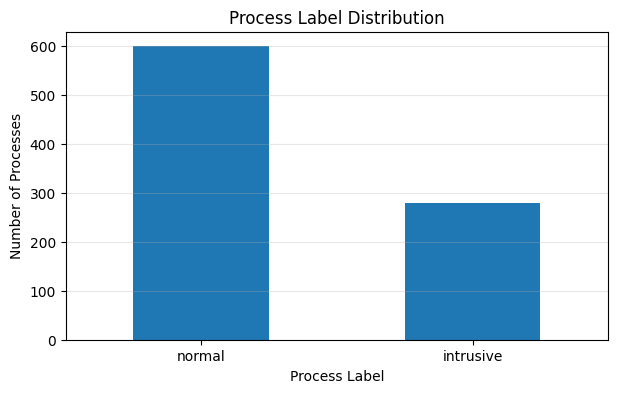

In [6]:
plt.figure(figsize=(7, 4))

df["label"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Process Label")
plt.ylabel("Number of Processes")
plt.title("Process Label Distribution")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [7]:
# Training contains only normal processes
train_df = df[
    (df["split"] == "train") &
    (df["label"] == "normal")
].copy()

# Test contains both normal and intrusive processes
test_df = df[
    df["split"] == "test"
].copy()

if len(train_df) == 0:
    raise ValueError("Training set is empty.")

if len(test_df) == 0:
    raise ValueError("Test set is empty.")

print("Training normal processes:", len(train_df))
print("Test processes:", len(test_df))

print("\nTest labels:")
display(test_df["label"].value_counts())

Training normal processes: 380
Test processes: 500

Test labels:


,count
label,
intrusive,280
normal,220


In [8]:
def tokenize_syscalls(s):
    """
    Convert a space-separated syscall sequence
    into a list of syscall tokens.
    """
    return [
        token
        for token in str(s).strip().split()
        if token
    ]


train_tokens = [
    tokenize_syscalls(s)
    for s in train_df["syscalls"].tolist()
]

test_tokens = [
    tokenize_syscalls(s)
    for s in test_df["syscalls"].tolist()
]

print("Example syscall sequence:")
print(train_tokens[0][:20])

Example syscall sequence:
['sigreturn', 'prlimit64', 'getpid', 'shmat', 'bind', 'readv', 'readv', 'getuid', 'getrlimit', 'nanosleep', 'bind', 'poll', 'listen', 'getpgrp', 'getsockopt', 'sendto', 'accept', 'setpgid', 'getppid', 'socket']


In [9]:
# Build vocabulary ONLY from normal training processes

vocab = sorted(
    set(
        token
        for document in train_tokens
        for token in document
    )
)

vocab_index = {
    word: index
    for index, word in enumerate(vocab)
}

M = len(vocab)

print("Number of unique syscalls:", M)

print("\nFirst 20 vocabulary terms:")
print(vocab[:20])

Number of unique syscalls: 95

First 20 vocabulary terms:
['accept', 'access', 'alarm', 'bind', 'brk', 'chmod', 'chown', 'clock_gettime', 'clone', 'close', 'connect', 'dup', 'dup2', 'dup3', 'execve', 'fcntl', 'fdatasync', 'flock', 'fork', 'fstat']


In [10]:
# Determine how many test syscalls were not observed
# in the normal training vocabulary.

train_vocab = set(vocab)

unseen_results = []

for process_id, tokens, label in zip(
    test_df["process_id"],
    test_tokens,
    test_df["label"]
):

    unseen = [
        token
        for token in tokens
        if token not in train_vocab
    ]

    total = len(tokens)

    unseen_results.append({
        "process_id": process_id,
        "label": label,
        "total_syscalls": total,
        "unseen_syscalls": len(unseen),
        "unseen_rate": (
            len(unseen) / total
            if total > 0
            else 0
        )
    })

unseen_df = pd.DataFrame(unseen_results)

display(unseen_df.head())

,process_id,label,total_syscalls,unseen_syscalls,unseen_rate
0,381,normal,78,0,0.0
1,382,normal,97,0,0.0
2,383,normal,111,0,0.0
3,384,normal,117,0,0.0
4,385,normal,76,0,0.0


In [11]:
unseen_summary = (
    unseen_df
    .groupby("label")["unseen_rate"]
    .agg(["mean", "median", "max"])
)

display(unseen_summary)

,mean,median,max
label,,,
intrusive,0.0,0.0,0.0
normal,0.0,0.0,0.0


<Figure size 700x400 with 0 Axes>

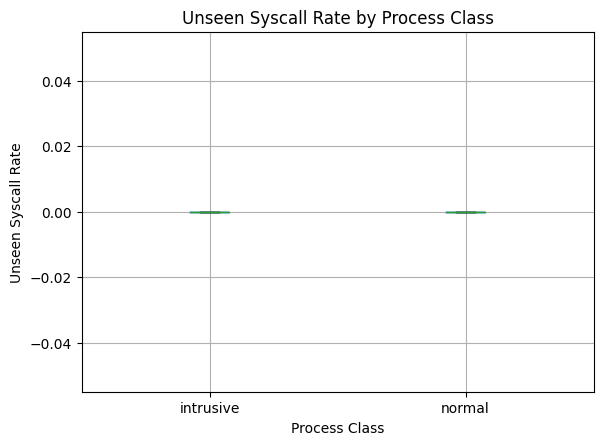

In [12]:
plt.figure(figsize=(7, 4))

unseen_df.boxplot(
    column="unseen_rate",
    by="label"
)

plt.title("Unseen Syscall Rate by Process Class")
plt.suptitle("")
plt.xlabel("Process Class")
plt.ylabel("Unseen Syscall Rate")

plt.show()

In [13]:
def compute_idf(
    docs_tokens,
    vocab_index,
    idf_mode="collection_count"
):

    N = len(docs_tokens)

    if idf_mode == "collection_count":

        total_counts = Counter()

        for doc in docs_tokens:
            total_counts.update(doc)

        idf = np.zeros(
            len(vocab_index),
            dtype=float
        )

        for word, index in vocab_index.items():

            count = total_counts.get(word, 0)

            denom = max(count, 1)

            idf[index] = math.log(
                N / denom
            )

        return idf

    elif idf_mode == "doc_freq":

        document_frequency = Counter()

        for doc in docs_tokens:
            document_frequency.update(
                set(doc)
            )

        idf = np.zeros(
            len(vocab_index),
            dtype=float
        )

        for word, index in vocab_index.items():

            frequency = document_frequency.get(
                word,
                0
            )

            denom = max(frequency, 1)

            idf[index] = math.log(
                N / denom
            )

        return idf

    else:
        raise ValueError(
            "idf_mode must be "
            "'collection_count' or 'doc_freq'"
        )

In [14]:
def vectorize_process(
    tokens,
    vocab_index,
    idf,
    normalize_tf=True
):

    vec = np.zeros(
        len(vocab_index),
        dtype=float
    )

    counts = Counter(tokens)

    # Term frequency
    for word, count in counts.items():

        if word in vocab_index:

            vec[vocab_index[word]] = float(
                count
            )

    # Normalize term frequency
    if normalize_tf:

        norm = np.linalg.norm(vec)

        if norm > 0:
            vec = vec / norm

    # Apply IDF
    vec = vec * idf

    return vec

In [15]:
# Primary experiment
idf_mode = "collection_count"

idf = compute_idf(
    train_tokens,
    vocab_index,
    idf_mode=idf_mode
)

print("IDF method:", idf_mode)
print("IDF vector size:", len(idf))

IDF method: collection_count
IDF vector size: 95


In [16]:
train_vecs = np.vstack([
    vectorize_process(
        document,
        vocab_index,
        idf
    )
    for document in train_tokens
])

test_vecs = np.vstack([
    vectorize_process(
        document,
        vocab_index,
        idf
    )
    for document in test_tokens
])

test_labels = test_df["label"].tolist()

print("Training vector shape:", train_vecs.shape)
print("Testing vector shape:", test_vecs.shape)

Training vector shape: (380, 95)
Testing vector shape: (500, 95)


In [17]:
def cosine_similarity(a, b):

    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)

    if norm_a == 0 or norm_b == 0:
        return 0.0

    return float(
        np.dot(a, b) /
        (norm_a * norm_b)
    )

In [18]:
def knn_anomaly_scores(
    train_vecs,
    test_vecs,
    k=10
):

    scores = []

    train_norms = np.linalg.norm(
        train_vecs,
        axis=1
    )

    for x in test_vecs:

        x_norm = np.linalg.norm(x)

        if x_norm == 0:
            scores.append(0.0)
            continue

        similarities = (
            np.dot(train_vecs, x) /
            (
                train_norms *
                x_norm
            )
        )

        similarities = np.nan_to_num(
            similarities,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        top_k = np.sort(
            similarities
        )[-k:]

        scores.append(
            float(np.mean(top_k))
        )

    return np.array(scores)

In [19]:
ks = [1, 3, 5, 10, 15, 25, 50]

score_data = {}

for k in ks:

    score_data[k] = knn_anomaly_scores(
        train_vecs,
        test_vecs,
        k=k
    )

print("Generated scores for k values:")
print(ks)

Generated scores for k values:
[1, 3, 5, 10, 15, 25, 50]


In [20]:
y_true = np.array([
    1 if label == "intrusive"
    else 0
    for label in test_labels
])

print("Normal processes:", np.sum(y_true == 0))
print("Intrusive processes:", np.sum(y_true == 1))

Normal processes: 220
Intrusive processes: 280


In [21]:
auc_results = []

for k in ks:

    scores = score_data[k]

    anomaly_scores = -scores

    auc_value = roc_auc_score(
        y_true,
        anomaly_scores
    )

    auc_results.append({
        "k": k,
        "ROC_AUC": auc_value
    })

auc_df = pd.DataFrame(
    auc_results
)

display(
    auc_df.sort_values(
        "ROC_AUC",
        ascending=False
    )
)

,k,ROC_AUC
5,25,0.961558
4,15,0.954221
6,50,0.949188
3,10,0.932516
2,5,0.897971
1,3,0.881705
0,1,0.852062


In [22]:
best_k = int(
    auc_df.loc[
        auc_df["ROC_AUC"].idxmax(),
        "k"
    ]
)

print("Best k based on ROC-AUC:", best_k)

Best k based on ROC-AUC: 25


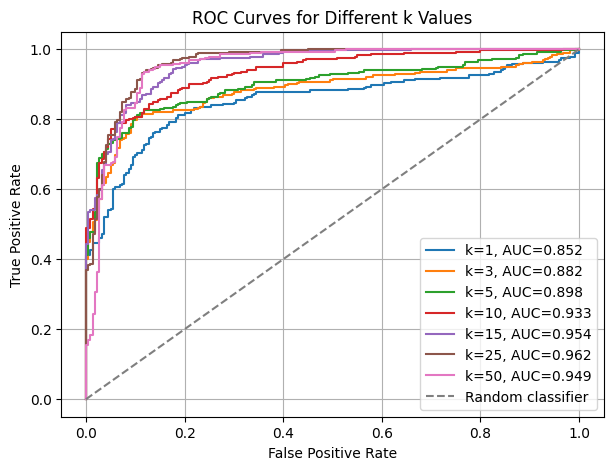

In [23]:
plt.figure(figsize=(7, 5))

for k in ks:

    anomaly_scores = -score_data[k]

    fpr, tpr, _ = roc_curve(
        y_true,
        anomaly_scores
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"k={k}, AUC={roc_auc:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Different k Values")

plt.grid(True)
plt.legend()

plt.show()

In [24]:
def evaluate_at_threshold(
    scores,
    labels,
    threshold
):

    y_true_intrusive = np.array([
        1 if label == "intrusive"
        else 0
        for label in labels
    ])

    # Lower similarity = more anomalous
    y_pred_intrusive = np.array([
        1 if score < threshold
        else 0
        for score in scores
    ])

    TP = int(
        (
            (y_true_intrusive == 1) &
            (y_pred_intrusive == 1)
        ).sum()
    )

    FN = int(
        (
            (y_true_intrusive == 1) &
            (y_pred_intrusive == 0)
        ).sum()
    )

    FP = int(
        (
            (y_true_intrusive == 0) &
            (y_pred_intrusive == 1)
        ).sum()
    )

    TN = int(
        (
            (y_true_intrusive == 0) &
            (y_pred_intrusive == 0)
        ).sum()
    )

    TPR = (
        TP / (TP + FN)
        if TP + FN > 0
        else 0
    )

    FPR = (
        FP / (FP + TN)
        if FP + TN > 0
        else 0
    )

    precision = (
        TP / (TP + FP)
        if TP + FP > 0
        else 0
    )

    recall = TPR

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if precision + recall > 0
        else 0
    )

    return {
        "TP": TP,
        "FN": FN,
        "FP": FP,
        "TN": TN,
        "TPR": TPR,
        "FPR": FPR,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

In [25]:
thresholds = [0.72, 0.80]

results = []

for k in ks:

    scores = score_data[k]

    for threshold in thresholds:

        metrics = evaluate_at_threshold(
            scores,
            test_labels,
            threshold
        )

        results.append({
            "k": k,
            "threshold": threshold,
            **metrics
        })

results_df = pd.DataFrame(results)

display(results_df)

,k,threshold,TP,FN,FP,TN,TPR,FPR,Precision,Recall,F1
0,1,0.72,229,51,44,176,0.817857,0.200000,0.838828,0.817857,0.828210
1,1,0.80,259,21,179,41,0.925000,0.813636,0.591324,0.925000,0.721448
2,3,0.72,243,37,61,159,0.867857,0.277273,0.799342,0.867857,0.832192
3,3,0.80,272,8,205,15,0.971429,0.931818,0.570231,0.971429,0.718626
4,5,0.72,250,30,74,146,0.892857,0.336364,0.771605,0.892857,0.827815
5,5,0.80,278,2,212,8,0.992857,0.963636,0.567347,0.992857,0.722078
6,10,0.72,272,8,104,116,0.971429,0.472727,0.723404,0.971429,0.829268
7,10,0.80,280,0,218,2,1.000000,0.990909,0.562249,1.000000,0.719794
8,15,0.72,279,1,135,85,0.996429,0.613636,0.673913,0.996429,0.804035
9,15,0.80,280,0,220,0,1.000000,1.000000,0.560000,1.000000,0.717949


In [26]:
best_result = results_df.loc[
    results_df["F1"].idxmax()
]

print("Best operating point:")
display(
    best_result.to_frame().T
)

Best operating point:


,k,threshold,TP,FN,FP,TN,TPR,FPR,Precision,Recall,F1
2,3.0,0.72,243.0,37.0,61.0,159.0,0.867857,0.277273,0.799342,0.867857,0.832192


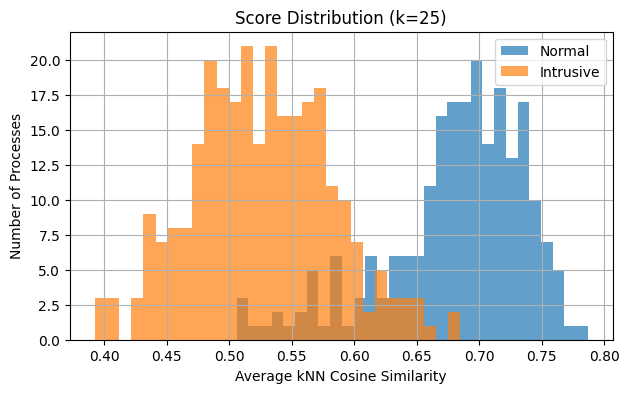

In [27]:
scores = score_data[best_k]

normal_scores = scores[y_true == 0]
intrusive_scores = scores[y_true == 1]

plt.figure(figsize=(7, 4))

plt.hist(
    normal_scores,
    bins=30,
    alpha=0.7,
    label="Normal"
)

plt.hist(
    intrusive_scores,
    bins=30,
    alpha=0.7,
    label="Intrusive"
)

plt.xlabel(
    "Average kNN Cosine Similarity"
)

plt.ylabel(
    "Number of Processes"
)

plt.title(
    f"Score Distribution (k={best_k})"
)

plt.legend()
plt.grid(True)

plt.show()

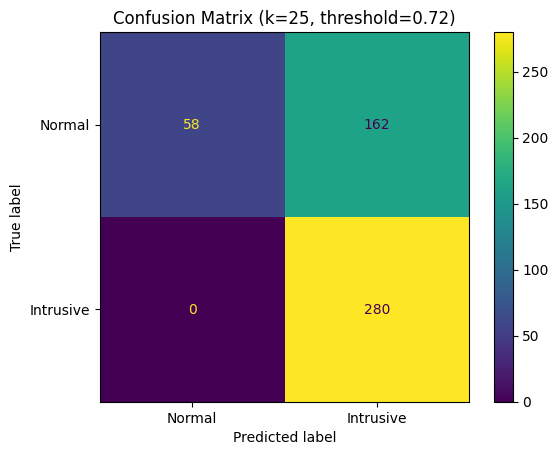

In [28]:
best_threshold = float(
    best_result["threshold"]
)

scores = score_data[best_k]

y_pred = np.array([
    1 if score < best_threshold
    else 0
    for score in scores
])

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal",
        "Intrusive"
    ]
)

disp.plot()

plt.title(
    f"Confusion Matrix "
    f"(k={best_k}, threshold={best_threshold})"
)

plt.show()

In [29]:
final_precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

final_recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

final_auc = roc_auc_score(
    y_true,
    -scores
)

print("FINAL MODEL PERFORMANCE")
print("=" * 40)

print(f"k:          {best_k}")
print(f"Threshold:  {best_threshold:.3f}")
print(f"ROC-AUC:    {final_auc:.4f}")
print(f"Precision:  {final_precision:.4f}")
print(f"Recall:     {final_recall:.4f}")
print(f"F1 Score:   {final_f1:.4f}")

FINAL MODEL PERFORMANCE
k:          25
Threshold:  0.720
ROC-AUC:    0.9616
Precision:  0.6335
Recall:     1.0000
F1 Score:   0.7756


In [30]:
idf_comparison = []

for method in [
    "collection_count",
    "doc_freq"
]:

    idf_test = compute_idf(
        train_tokens,
        vocab_index,
        idf_mode=method
    )

    train_vectors = np.vstack([
        vectorize_process(
            doc,
            vocab_index,
            idf_test
        )
        for doc in train_tokens
    ])

    test_vectors = np.vstack([
        vectorize_process(
            doc,
            vocab_index,
            idf_test
        )
        for doc in test_tokens
    ])

    scores_method = knn_anomaly_scores(
        train_vectors,
        test_vectors,
        k=best_k
    )

    auc_method = roc_auc_score(
        y_true,
        -scores_method
    )

    idf_comparison.append({
        "IDF Method": method,
        "k": best_k,
        "ROC-AUC": auc_method
    })

idf_comparison_df = pd.DataFrame(
    idf_comparison
)

display(idf_comparison_df)

,IDF Method,k,ROC-AUC
0,collection_count,25,0.961558
1,doc_freq,25,0.979318


In [31]:
threshold_grid = np.linspace(
    scores.min(),
    scores.max(),
    100
)

threshold_results = []

for threshold in threshold_grid:

    metrics = evaluate_at_threshold(
        scores,
        test_labels,
        threshold
    )

    threshold_results.append({
        "threshold": threshold,
        **metrics
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(
    threshold_df.head()
)

,threshold,TP,FN,FP,TN,TPR,FPR,Precision,Recall,F1
0,0.392525,0,280,0,220,0.000000,0.0,0.0,0.000000,0.000000
1,0.396508,1,279,0,220,0.003571,0.0,1.0,0.003571,0.007117
2,0.400492,2,278,0,220,0.007143,0.0,1.0,0.007143,0.014184
3,0.404475,3,277,0,220,0.010714,0.0,1.0,0.010714,0.021201
4,0.408458,5,275,0,220,0.017857,0.0,1.0,0.017857,0.035088


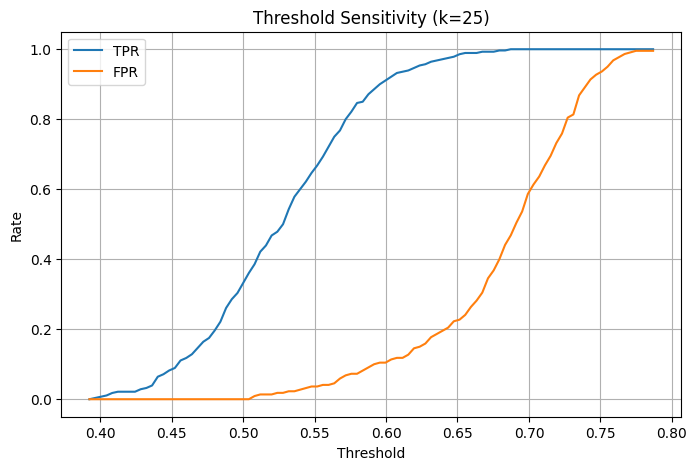

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["TPR"],
    label="TPR"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["FPR"],
    label="FPR"
)

plt.xlabel("Threshold")
plt.ylabel("Rate")

plt.title(
    f"Threshold Sensitivity (k={best_k})"
)

plt.grid(True)
plt.legend()

plt.show()

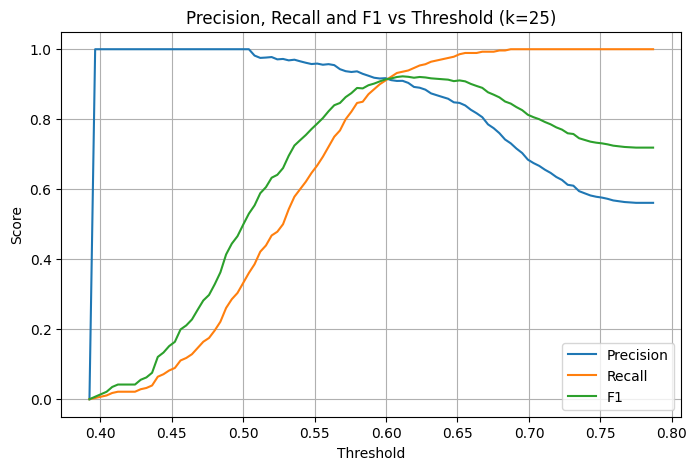

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title(
    f"Precision, Recall and F1 vs Threshold "
    f"(k={best_k})"
)

plt.grid(True)
plt.legend()

plt.show()

In [34]:
final_results = pd.DataFrame({
    "Metric": [
        "Training Processes",
        "Test Processes",
        "Vocabulary Size",
        "Best k",
        "Best Threshold",
        "ROC-AUC",
        "TPR / Recall",
        "FPR",
        "Precision",
        "F1 Score"
    ],
    "Value": [
        len(train_df),
        len(test_df),
        M,
        best_k,
        best_threshold,
        final_auc,
        final_recall,
        evaluate_at_threshold(
            scores,
            test_labels,
            best_threshold
        )["FPR"],
        final_precision,
        final_f1
    ]
})

display(final_results)

,Metric,Value
0,Training Processes,380.000000
1,Test Processes,500.000000
2,Vocabulary Size,95.000000
3,Best k,25.000000
4,Best Threshold,0.720000
5,ROC-AUC,0.961558
6,TPR / Recall,1.000000
7,FPR,0.736364
8,Precision,0.633484
9,F1 Score,0.775623


# Conclusion

The system-call intrusion detection approach uses normal processes as the training population and identifies anomalous processes using TF-IDF-inspired representations, cosine similarity, and kNN-based anomaly scoring.

The experiments evaluate multiple values of k and different decision thresholds using ROC-AUC, TPR, FPR, Precision, Recall, and F1 score.

The analysis also investigates:

- The distribution of normal and intrusive processes
- Unseen system calls in the test set
- The effect of k on detection performance
- Threshold sensitivity
- Alternative IDF formulations
- Confusion-matrix performance

The final model configuration is selected based on quantitative evaluation rather than choosing k arbitrarily.